#### library import

In [54]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
from seaborn import heatmap
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.metrics import Recall

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

import pickle

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

from sklearn.utils.validation import check_random_state
check_random_state(42)

RandomState(MT19937) at 0x74D80DABFE40

#### constants

In [2]:
DATA_DIR = '../../data/raw'
COLUMNS_INFO = '../../columns-info.csv'
DATASET = f'{DATA_DIR}/dataset_practica_final.csv'
MODEL_DIR = '../../models'
RandomForestClassifierModel = f'{MODEL_DIR}/RandomForestClassifierModel.pkl'
NeuralNetworkModel = f'{MODEL_DIR}/NeuralNetworkModel.pkl'

#### data load

In [3]:
dset = pd.read_csv(DATASET)
dset_cp = dset.copy()

#### feature anlysis

In [25]:
columns_info = pd.DataFrame({
'hotel':['cat', 'keep', ''],
'is_canceled':['cat', 'keep', 'target, dataset ligeramente desblanceado (63%, 37%)'],
'lead_time':['num', 'keep', ''],
'arrival_date_year':['ord', 'drop', 'el año en que se hizo la reserva no tiene valor para predecir a futro, En todo caso se usa para ver si hay correlación entre la relación de cancelado/no_cancelado y el año, en cuyo caso el dataset no sería coherente y se debería fraccionar en partes homogéneas y tomar la parte más reciente para predecir a futuro. En este caso no se ha visto esa correlación, por lo que se mantiene el dataset entero.'],
'arrival_date_month':['ord', 'drop', 'redundante con arrival_dat_week_number'],
'arrival_date_week_number':['ord', 'keep', ''],
'arrival_date_day_of_month':['ord', 'drop', 'redundante con arrival_dat_week_number'],
'stays_in_weekend_nights':['num', 'keep', ''],
'stays_in_week_nights':['num', 'keep', ''],
'adults':['num', 'keep','drop rows with 0'],
'children':['num', 'drop', 'está muy desbalanceada y en entrenamiento RFC se ha visto que estáa entre las variables menos significativasa, se quita, obteniendo una ligera mejora en el recall'],
'babies':['num', 'drop', 'drop >8. está muy desbalanceada y en entrenamiento RFC se ha visto que estáa entre las variables menos significativasa, se quita, obteniendo una ligera mejora en el recall'],
'meal':['cat', 'keep',''],
'country':['cat', 'keep', 'mucahs categorías, muchas de ellas con baja frecuencia. Se agrupan en "other" las características con menos frecuencia'],
'market_segment':['cat', 'keep', ''],
'distribution_channel':['cat', 'keep', ''],
'is_repeated_guest':['cat', 'keep', 'muy desbalanceada'],
'previous_cancellations':['num','keep',''],
'previous_bookings_not_canceled':['num', 'keep','conjuntamente con previous_cancellations da un ratio de cancelación pasado por cliente'],
'reserved_room_type':['cat', 'keep', ''],
'assigned_room_type':['cat', 'keep', 'la reserva puede ser cancelado in-situ si la habitación asignada es distinta de la reservada y no satisface las expectativas del cliente'],
'booking_changes':['num','keep',''],
'deposit_type':['cat','keep',''],
'agent':['cat', 'keep', 'nan se interpreta como que el clilente no ha usado agente. muchas clases, muchas de baja frecuencia. todas las clases menos frecuentes que la "sin agtente" se agrupan en una'],
'company':['cat','keep','nan se interpreta como que el cliente no viaja por empresa. fueremente desbalanceada y atomizada. se convierte en binaria (si es cliene tipo empresa o no)'],
'days_in_waiting_list':['num', 'keep', ''],
'customer_type':['cat', 'keep', ''],
'adr':['num', 'keep', ''],
'required_car_parking_spaces':['num','keep',''],
'total_of_special_requests':['num', 'keep',''],
'reservation_status':['cat', 'drop','irrelevante, se da después de haberse dado la target (is_canceled). de inmcluirse se incurriría en data leakage'], 
'reservation_status_date':['cat','drop', 'irrelevante, es una propiedad de una irrelevante (la de justo arriba)']}).T
columns_info.columns = ['type', 'kd', 'comment']
columns_info

,type,kd,comment
hotel,cat,keep,
is_canceled,cat,keep,"target, dataset ligeramente desblanceado (63%,..."
lead_time,num,keep,
arrival_date_year,ord,drop,el año en que se hizo la reserva no tiene valo...
arrival_date_month,ord,drop,redundante con arrival_dat_week_number
arrival_date_week_number,ord,keep,
arrival_date_day_of_month,ord,drop,redundante con arrival_dat_week_number
stays_in_weekend_nights,num,keep,
stays_in_week_nights,num,keep,
adults,num,keep,drop rows with 0


#### carga y procesado de los datos

In [26]:
def loader(dataset_csv_filename:str, columns_info, OHE:bool) -> (pd.core.frame.DataFrame, pd.core.frame.DataFrame, pd.core.series.Series, pd.core.series.Series):
    '''
    dataset_csv_filename: ruta al csv con los datos
    OHE: si es true, los campos categóricos se condifican con OneHotEncoder. 
         si false los campos de texto se codifican a categoría y después a numérico usando sus códigos
    '''

    # carga del csv en un dataframe
    dset = pd.read_csv(dataset_csv_filename)

    # se aletatoriza la posición de las filas del dataset
    dset = dset.sample(frac=1).reset_index(drop=True)
    
    # Eliminación de variables con fugas de datos (Data Leakage)
    columns_to_drop = columns_info[columns_info.kd=='drop'].index
    dset.drop(columns_to_drop, axis= 1, inplace=True)

    # --- LIMPIEZA DE ANOMALÍAS ---
    
    # Reemplazar el valor negativo por la mediana
    if columns_info.loc['adr','kd'] == 'keep':
        dset.loc[dset['adr'] < 0, 'adr'] = dset['adr'].median()

    # Eliminar las filas con 0 adultos
    if columns_info.loc['adults','kd'] == 'keep':
        dset = dset[dset['adults'] != 0]

    # Eliminar las filas con 10 niños y mas de 8 bebes
    if columns_info.loc['children','kd'] == 'keep':
        dset = dset[dset['children'] != 10]
    if columns_info.loc['babies','kd'] == 'keep':
        dset = dset[dset['babies'] < 8]

    # --- LIMPIEZA DE ANOMALÍAS ---


    # Agrupar países con poca representación
    if columns_info.loc['country','kd'] == 'keep':
        top_countries = dset['country'].value_counts().nlargest(10).index
        dset['country'] = dset['country'].where(dset['country'].isin(top_countries), 'Other')

    # Convertir el mes a valor numérico para mantener la temporalidad
    #month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    #             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
    #dset['arrival_date_month'] = dset['arrival_date_month'].map(month_map)

    # Simplificar Compañía a variables binarias
    if columns_info.loc['company','kd'] == 'keep':
        dset['has_company'] = dset['company'].notnull().astype(int)
    
    # procesado del campo Agent
    if columns_info.loc['agent','kd'] == 'keep':
        # las reservas que no han usado agente están a na. Se sustituye por 0, que es un código no usado
        dset['agent'] = dset['agent'].fillna(0)
        # Agrupar agentes con poca representación. El caso 'sin agente' está en el ranking 11. Se le asigna ell código 40, que no està entre los 10 de mayor frecuéncia
        top_agents = dset['agent'].value_counts().nlargest(11).index
        dset['agent'] = dset['agent'].where(dset['agent'].isin(top_agents), 40)
    
    # relleno de los valores faltantes
    if columns_info.loc['children','kd'] == 'keep':    
        dset['children'] = dset['children'].fillna(dset['children'].median())

    # separación en target (variable objetivo) y features
    y = dset['is_canceled']
    X = dset.drop(['is_canceled'], axis=1)
   
    # OneHot encoder de las variables categóricas (no ordinales)
    list_one_hot_cols = []
    if OHE:
        list_one_hot_cols = [c for c in X.columns if c in columns_info[columns_info.type=='cat'].index]
    else:
        # primero se ponen en una lista los cmps de texto
        # después se convierten los campos a catgorías, se toman sus códigos numéricos (.cat.codes) y se sustitye a los string originales por ellos
        text_fields = [c for c in X.columns if X_train[c].dtype==object]
        for c in text_fields:
            X[c] = X[c].astype('category').cat.codes  

    # Mejor hacer la lista dinámica, para que no se pierda nada
    list_numeric_cols = [col for col in X.columns if col not in list_one_hot_cols]

    columns_preprocessor = ColumnTransformer(transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), list_one_hot_cols),
        #('one_hot', OneHotEncoder(drop='if_binary', sparse_output=False), list_one_hot_cols),
        #('ordinal', OrdinalEncoder(), list_ordinal_cols),
        ('numeric', MinMaxScaler(), list_numeric_cols)
    ])

    # fit_transform solo en train, transform en test
    #X_train_processed = columns_preprocessor.fit_transform(X_train)
    #X_test_processed = columns_preprocessor.transform(X_test)
    X_processed_arr = columns_preprocessor.fit_transform(X)

    # Restaurar a DataFrame para no perder los nombres
    nombres_columnas = columns_preprocessor.get_feature_names_out()
    
    # Se limpia el texto que añade scikit-learn por defecto
    nombres_columnas = [nombre.replace('one_hot__', '').replace('numeric__', '') for nombre in nombres_columnas]

    X_processed = pd.DataFrame(X_processed_arr, columns=nombres_columnas, index=X.index)
    #X_test = pd.DataFrame(X_test_processed, columns=nombres_columnas, index=X_test.index)

    # train_test_split se hace antes de trasnformar nada
    X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, stratify=y)
    
    return (X_train, X_test, y_train, y_test)

In [27]:
X_train, X_test, y_train, y_test = loader(DATASET, columns_info, True)

#### RandomForestCalssifier
- se hace una búsqueda de hiperparámetros óptimos vía GridSearchCV
- se saca la importancia de las features en la clasificación
- se scan las métricas de clasificación
- se serializa el modelo en un pkl

In [76]:
# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'n_estimators': [50, 100, 300],
    'max_depth': [8,10,12], #[6,8,10],
    'class_weight': ['balanced'],
    'n_jobs': [-1]
}
# Entrenamiento de un modelo de RandomForest Classifier. Por defecto el recall es el de la clase 1 (pos_labelint, float, bool or str, default=1)
modelo_rfc = RandomForestClassifier()
modelo_rfc_cv = GridSearchCV(modelo_rfc, dict_parametros, cv=5, scoring='recall')
modelo_rfc_cv.fit(X_train, y_train)

# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_rfc_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rfc_cv.best_score_:.2%}")

# se obtienen los mejors hiperparámetros
modelo_rfc_cv.best_estimator_

Mejores hiperparámetros encontrados: {'class_weight': 'balanced', 'max_depth': 12, 'n_estimators': 300, 'n_jobs': -1}
Mejor score obtenido: 80.95%


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [29]:
# cremos el modelo con los mejores hiperparámetros encontrados (n_estimatimators=200, max_depth=12) y lo entrenamos:
model_rfc = RandomForestClassifier(n_estimators=50, max_depth=12, class_weight='balanced', n_jobs=-1)
model_rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [30]:
# Feature importance
importances = model_rfc.feature_importances_
feature_imp = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
feature_imp.head(15)

,Feature,Gini Importance
45,deposit_type_Non Refund,0.164362
14,country_PRT,0.117230
409,lead_time,0.090243
420,total_of_special_requests,0.077340
414,previous_cancellations,0.052985
419,required_car_parking_spaces,0.047114
416,booking_changes,0.035233
407,customer_type_Transient,0.029703
18,market_segment_Groups,0.023081
51,agent_9.0,0.021630


In [31]:
import re
feature_importance = {c:0 for c in dset.columns}
for index,row in feature_imp.iterrows():
    for feature in feature_importance.keys():
        sr = re.search(feature, row['Feature'])
        if sr:
            feature_importance[sr.group()] += row['Gini Importance']

In [32]:
pd.Series(dict(sorted(feature_importance.items(), key = lambda item: item[1], reverse=True)))

deposit_type                      0.164480
country                           0.157555
lead_time                         0.090243
agent                             0.086862
total_of_special_requests         0.077340
market_segment                    0.075844
previous_cancellations            0.052985
required_car_parking_spaces       0.047114
customer_type                     0.044769
distribution_channel              0.037163
booking_changes                   0.035233
assigned_room_type                0.021440
adr                               0.019263
company                           0.015243
previous_bookings_not_canceled    0.013291
reserved_room_type                0.009919
hotel                             0.009884
stays_in_week_nights              0.008846
arrival_date_week_number          0.007884
adults                            0.005560
meal                              0.005441
stays_in_weekend_nights           0.005309
is_repeated_guest                 0.005063
days_in_wai

In [33]:
# 2. Guardamos rfc ganador usando la ruta de tu config.py
joblib.dump(model_rfc, RandomForestClassifierModel)

['../../models/RandomForestClassifierModel.pkl']

In [34]:
# Hacemos predicciones sobre el conjunto de test con los mejores parñametros obtenidos:
y_pred_rfc = model_rfc.predict(X_test)

In [35]:
# Report de métricas
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88     14975
           1       0.80      0.80      0.80      8823

    accuracy                           0.85     23798
   macro avg       0.84      0.84      0.84     23798
weighted avg       0.85      0.85      0.85     23798



#### Neural Network

In [66]:
# Definimos la arquitectura del modelo
model_nn = models.Sequential(layers=[
    layers.Input(shape=(X_train.shape[1],), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilamos el modelo (recall se refiere por definición a la clase 1 en la funcón usada)
optimizer_adam = Adam(learning_rate=0.001)
model_nn.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=[Recall()])

Se observa que el modelo converge rápidamente; ha estado bien cortar temprano porqué ya no había gananccia el loss y val_loss tenía tendencia creciente (la ganancia en loss iba a ser por overfitting)

In [67]:
%%time
# Se entrena el modelo con un callback de early stopping. Se aplic en el val_loss porqué no se quiere overfitting
callback = EarlyStopping(monitor="val_loss",
                         min_delta=0.02,
                         patience=3,  # número de veces con una ganancia por debajo de la mínima seguidas antes de parar
                         verbose=0,
                         mode="auto",
                         baseline=None,
                         restore_best_weights=False,
                         start_from_epoch=0,
                        )
#history = model_nn.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=1, callbacks=[callback])
history = model_nn.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=1, callbacks=[callback])

Epoch 1/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.3534 - recall_5: 0.7208 - val_loss: 0.3289 - val_recall_5: 0.6959
Epoch 2/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.3174 - recall_5: 0.7580 - val_loss: 0.3187 - val_recall_5: 0.7591
Epoch 3/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3073 - recall_5: 0.7627 - val_loss: 0.3116 - val_recall_5: 0.7431
Epoch 4/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.3000 - recall_5: 0.7678 - val_loss: 0.3063 - val_recall_5: 0.7721
Epoch 5/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2955 - recall_5: 0.7724 - val_loss: 0.3050 - val_recall_5: 0.7653
Epoch 6/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.2900 - recall_5: 0.7781 - val_loss: 0.3040 - val_recall_5: 0.7670
Epoch 7/100
2380/2380 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2856 - recall_5: 0.7849 - val_loss: 0.3074 - val_recall_5: 0.8379
CPU times: user 1min 25s, sys: 30.8 s, total: 1min 56s
Wall time: 1min 7s


In [68]:
# 2. Guardamos rfc ganador usando la ruta de tu config.py
joblib.dump(model_nn, NeuralNetworkModel)

['../../models/NeuralNetworkModel.pkl']

In [69]:
y_pred = model_nn.predict(X_test)
y_pred_nn = pd.Series(y_pred.flatten()).map(lambda x: 1 if x > 0.5 else 0)

744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [70]:
# Report de métricas
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88     14975
           1       0.79      0.84      0.81      8823

    accuracy                           0.86     23798
   macro avg       0.85      0.85      0.85     23798
weighted avg       0.86      0.86      0.86     23798



#### Model comparison

- Carga de los modelos y càlculo de predicciones

In [71]:
# carga de modelos y generación de predicciones
#y_preds = {'model_name': [y_pred, y_proba])
y_preds = dict()
with open(RandomForestClassifierModel, 'rb') as f:
    model_rfc = joblib.load(f)
y_preds['RandomForestClassifierModel']= [model_rfc.predict(X_test),
                                         pd.Series(model_rfc.predict_proba(X_test)[:,1])]

with open(NeuralNetworkModel, 'rb') as f:
    model_rfc = joblib.load(f)
y_pr = model_nn.predict(X_test).flatten()
y_preds['NeuralNetworkModel'] = [pd.Series(y_pr).map(lambda x: 1 if x > 0.5 else 0),
                                 pd.Series(y_pr)]

744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


- Generación de classification reports

In [72]:
for model in y_preds:
    print('=================================================================')
    print(f'{model} classification report')
    print(classification_report(y_test, y_preds[model][0]))
    print('=================================================================')

RandomForestClassifierModel classification report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     14975
           1       0.80      0.80      0.80      8823

    accuracy                           0.85     23798
   macro avg       0.84      0.84      0.84     23798
weighted avg       0.85      0.85      0.85     23798

NeuralNetworkModel classification report
              precision    recall  f1-score   support

           0       0.90      0.87      0.88     14975
           1       0.79      0.84      0.81      8823

    accuracy                           0.86     23798
   macro avg       0.85      0.85      0.85     23798
weighted avg       0.86      0.86      0.86     23798



- Confusion Matrices

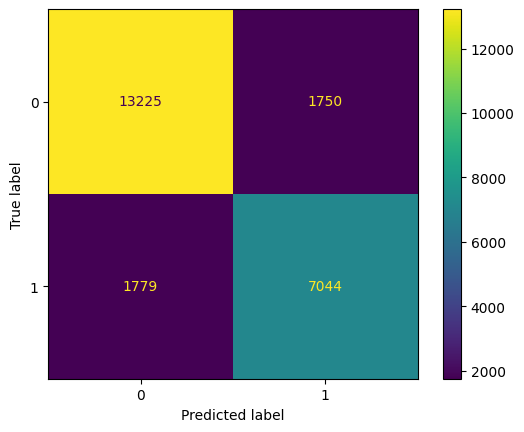

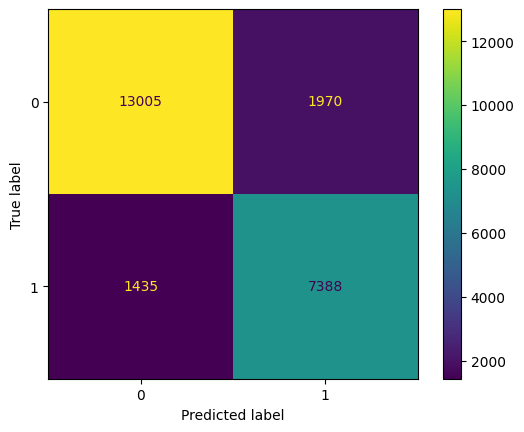

In [73]:
# Generamos una matriz de confusión que permitirá ver cuántas son las predicciones correctas y cuántas incorrectas
for model in y_preds:
    cm = confusion_matrix(y_test, y_preds[model][0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

- ROC (Receiver Operating Characteristic)

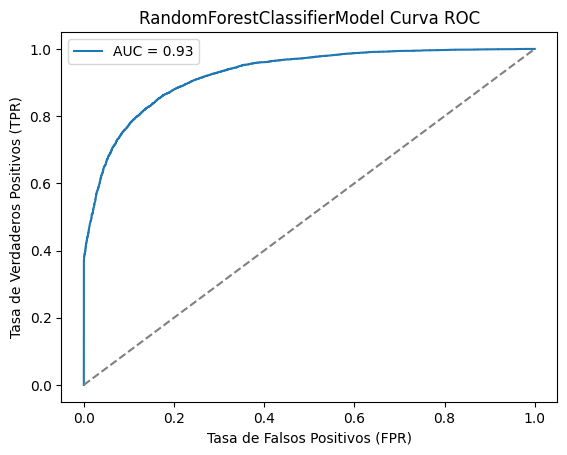

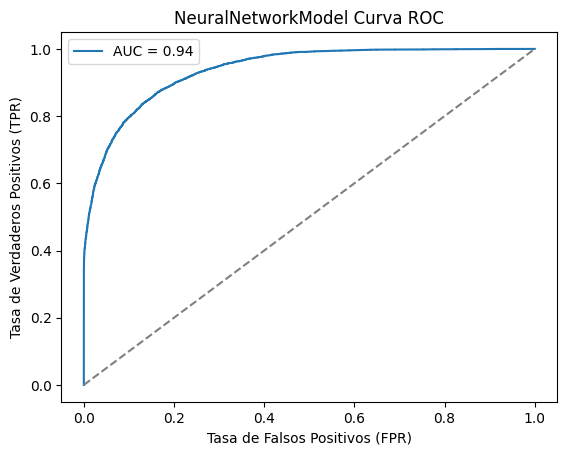

In [74]:
# Curva ROC
for model in y_preds:
    fpr, tpr, thresholds = roc_curve(y_test, y_preds[model][1])
    auc = roc_auc_score(y_test, y_preds[model][1])
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'{model} Curva ROC')
    plt.legend()
    plt.show()

In [75]:
import re
[c for c in X_train.columns if re.search('agent', c)]

['agent_1.0',
 'agent_6.0',
 'agent_7.0',
 'agent_8.0',
 'agent_9.0',
 'agent_14.0',
 'agent_28.0',
 'agent_40.0',
 'agent_240.0',
 'agent_241.0',
 'agent_250.0']